# Metode Newton-Raphson

**Mata Kuliah:** Metode Numerik
**Universitas Gadjah Mada**

---

## Dasar Teori

Metode Newton-Raphson adalah metode iteratif untuk mencari akar persamaan $f(x) = 0$ menggunakan informasi turunan fungsi. Metode ini memiliki konvergensi kuadratik, artinya jumlah digit yang benar kira-kira berlipat dua setiap iterasi.

### Rumus Iterasi

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

### Algoritma

1. Tentukan tebakan awal $x_0$
2. Hitung $f(x_n)$ dan $f'(x_n)$
3. Hitung $x_{n+1}$ menggunakan rumus di atas
4. Hitung error $\Delta x = |x_{n+1} - x_n|$
5. Ulangi hingga $\Delta x < \varepsilon$ (toleransi) atau iterasi maksimum tercapai

### Kelebihan
- Konvergensi sangat cepat (kuadratik)
- Cocok untuk fungsi yang licin dan dapat diturunkan

### Keterbatasan
- Membutuhkan turunan fungsi $f'(x)$
- Dapat divergen jika tebakan awal $x_0$ jauh dari akar
- Gagal jika $f'(x_n) = 0$ (turunan mendekati nol)

## Import Library

In [18]:
from sympy import symbols, diff, lambdify, pprint
import matplotlib.pyplot as plt
import numpy as np

## Definisi Fungsi

Fungsi yang digunakan:

$$f(x) = x^5 - 3x^4 - 2x^3 + 9x^2 - 10x + 1$$

Turunan dihitung secara otomatis menggunakan `sympy.diff()`.

In [19]:
x = symbols('x')

f_sym  = x**5 - 3*x**4 - 2*x**3 + 9*x**2 - 10*x + 1
df_sym = diff(f_sym, x)

print("f(x)  =")
pprint(f_sym)
print()
print("f'(x) =")
pprint(df_sym)

# Konversi ke fungsi numerik
f  = lambdify(x, f_sym,  'numpy')
df = lambdify(x, df_sym, 'numpy')

f(x)  =
 5      4      3      2           
x  - 3⋅x  - 2⋅x  + 9⋅x  - 10⋅x + 1

f'(x) =
   4       3      2            
5⋅x  - 12⋅x  - 6⋅x  + 18⋅x - 10


## Implementasi Metode Newton-Raphson

Fungsi berikut mendukung dua mode:
- **`tolerance`** — iterasi berhenti saat $\Delta x < \varepsilon$
- **`iteration`** — iterasi berhenti setelah sejumlah iterasi maksimum

In [20]:
def newton_raphson(x0, tol=1e-6, max_iter=100, mode='tolerance'):
    """
    Mencari akar f(x) = 0 menggunakan metode Newton-Raphson.

    Parameters
    ----------
    x0       : float  — tebakan awal
    tol      : float  — toleransi error (mode='tolerance')
    max_iter : int    — jumlah iterasi maksimum (mode='iteration')
    mode     : str    — 'tolerance' atau 'iteration'

    Returns
    -------
    x_new   : float — aproksimasi akar
    iterasi : int   — jumlah iterasi yang dilakukan
    """
    x_curr  = x0
    iterasi = 0
    x_new   = x0

    print(f"{'Iterasi':<8} {'x':<18} {'f(x)':<18} {'Δx':<15}")
    print("-" * 60)

    while True:
        iterasi += 1
        fx  = f(x_curr)
        dfx = df(x_curr)

        if abs(dfx) < 1e-10:
            print("Turunan mendekati nol — metode berhenti.")
            break

        x_new = x_curr - fx / dfx
        dx    = abs(x_new - x_curr)

        print(f"{iterasi:<8} {x_curr:<18.8f} {fx:<18.8f} {dx:<15.8f}")

        if mode == 'tolerance' and dx < tol:
            break
        elif mode == 'iteration' and iterasi >= max_iter:
            break

        x_curr = x_new

    return x_new, iterasi

## Mode 1 — Berdasarkan Toleransi

Iterasi berhenti ketika $\Delta x < 10^{-6}$.

In [21]:
print("MODE 1 — Toleransi (tol = 1e-6)\n")
root1, iter1 = newton_raphson(x0=0.5, tol=1e-6, mode='tolerance')
print(f"\nHasil:")
print(f"  Akar     : {root1:.10f}")
print(f"  Iterasi  : {iter1}")
print(f"  f(akar)  : {f(root1):.2e}")

MODE 1 — Toleransi (tol = 1e-6)

Iterasi  x                  f(x)               Δx             
------------------------------------------------------------
1        0.50000000         -2.15625000        0.58474576     
2        -0.08474576        1.91315238         0.16548396     
3        0.08073820         0.25010925         0.02910979     
4        0.10984800         0.00704749         0.00086895     
5        0.11071695         0.00000614         0.00000076     

Hasil:
  Akar     : 0.1107177084
  Iterasi  : 5
  f(akar)  : 4.68e-12


## Mode 2 — Berdasarkan Jumlah Iterasi

Iterasi berhenti setelah 10 iterasi tanpa memeriksa toleransi.

In [22]:
print("MODE 2 — Iterasi Tetap (max_iter = 10)\n")
root2, iter2 = newton_raphson(x0=0.5, max_iter=10, mode='iteration')
print(f"\nHasil:")
print(f"  Akar     : {root2:.10f}")
print(f"  Iterasi  : {iter2}")
print(f"  f(akar)  : {f(root2):.2e}")

MODE 2 — Iterasi Tetap (max_iter = 10)

Iterasi  x                  f(x)               Δx             
------------------------------------------------------------
1        0.50000000         -2.15625000        0.58474576     
2        -0.08474576        1.91315238         0.16548396     
3        0.08073820         0.25010925         0.02910979     
4        0.10984800         0.00704749         0.00086895     
5        0.11071695         0.00000614         0.00000076     
6        0.11071771         0.00000000         0.00000000     
7        0.11071771         0.00000000         0.00000000     
8        0.11071771         0.00000000         0.00000000     
9        0.11071771         0.00000000         0.00000000     
10       0.11071771         0.00000000         0.00000000     

Hasil:
  Akar     : 0.1107177084
  Iterasi  : 10
  f(akar)  : 0.00e+00


C:\Users\INTEL G4560\AppData\Local\Temp\ipykernel_3056\848405520.py:33: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()


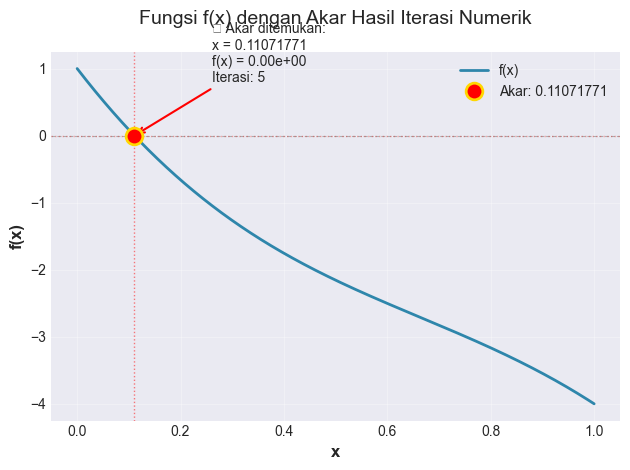

In [27]:
x_val = np.arange(0, 1, 0.000001)
y_f = f(x_val)
plt.plot(x_val, y_f, color='#2E86AB', linewidth=2, label='f(x)', zorder=3)

# Garis y = 0 referensi
plt.axhline(0, color='gray', linewidth=0.8, alpha=0.6, linestyle='--')

# 🎯 Highlight akar hasil iterasi
plt.plot(root2, f(root2), 'ro', markersize=12, zorder=5, 
         markeredgecolor='red', markeredgewidth=2, label=f'Akar: {root2:.8f}')

# Garis vertikal & horizontal ke akar
plt.axvline(root2, color='red', linestyle=':', alpha=0.5, linewidth=1)
plt.axhline(f(root2), color='red', linestyle=':', alpha=0.3, linewidth=1)

# Annotation box hasil
plt.annotate(
    f'🎯 Akar ditemukan:\nx = {root2:.8f}\nf(x) = {f(root2):.2e}\nIterasi: 5',
    xy=(root2, f(root2)),
    xytext=(root2 + 0.15, f(root2) + 0.8),
    fontsize=10,
    #bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='orange'),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

# Labels & title
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('f(x)', fontsize=12, fontweight='bold')
plt.title('Fungsi f(x) dengan Akar Hasil Iterasi Numerik', fontsize=14, pad=20)
plt.legend(fontsize=10, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Kesimpulan

- Metode Newton-Raphson berhasil menemukan akar $f(x) = x^5 - 3x^4 - 2x^3 + 9x^2 - 10x + 1$ dengan tebakan awal $x_0 = 0.5$.
- Mode toleransi menghasilkan akar yang lebih akurat karena iterasi berlanjut hingga error sekecil yang ditentukan.
- Mode iterasi tetap berguna untuk membatasi komputasi, namun akurasi bergantung pada jumlah iterasi yang dipilih.
- Nilai $f(\text{akar}) \approx 0$ mengkonfirmasi bahwa akar yang ditemukan valid.